### **Week 1: Data Understanding, Cleaning & Feature Engineering**
In this section, we load the Telecom Customer Churn dataset to prepare it for analysis. The focus is on handling incorrect data types (specifically converting `TotalCharges` to numeric), managing missing values, and engineering new features such as `TenureGroup` and `AvgMonthlySpend` to better segment our customers. We also format binary and categorical variables to ensure the data is mathematically ready for analysis.

In [3]:
import pandas as pd
import numpy as np

# 1. Data Understanding
df_churn = df_churn = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df_churn.info()) # Print info [cite: 13]
print(df_churn.describe()) # Print describe [cite: 13]

# 2. Data Cleaning
# Fix data types (TotalCharges is object -> float) and handle missing/strange values like "" [cite: 15, 18]
df_churn['TotalCharges'] = pd.to_numeric(df_churn['TotalCharges'], errors='coerce')
df_churn = df_churn.dropna() # Handle missing values by dropping them [cite: 19]

# 3. Feature Engineering
# Create TenureGroup (0-12 months, 13-24, etc.) [cite: 25]
bins = [0, 12, 24, 36, 48, 60, 72]
labels = ['0-12', '13-24', '25-36', '37-48', '49-60', '61-72']
df_churn['TenureGroup'] = pd.cut(df_churn['tenure'], bins=bins, labels=labels, right=False)

# Create AvgMonthlySpend = TotalCharges / Tenure [cite: 26]
# Adding a small number to tenure to avoid division by zero
df_churn['AvgMonthlySpend'] = df_churn['TotalCharges'] / (df_churn['tenure'] + 0.0001)

# Convert binary yes/no to 1/0 [cite: 27, 28]
binary_columns = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_columns:
    df_churn[col] = df_churn[col].map({'Yes': 1, 'No': 0})

# One-hot encode categorical columns like Contract, InternetService [cite: 29]
df_churn = pd.get_dummies(df_churn, columns=['Contract', 'InternetService'])

print("Week 1 Data Prep Complete!")
print(df_churn.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### **Week 2: Exploratory Data Analysis (EDA) & Visualizing Churn**
With the data cleaned, we shift to visualizing the relationships between customer attributes and their likelihood to churn. Using Seaborn and Matplotlib, we generate plots to explore contract types, monthly charges, and overall churn distribution. Finally, we compute a correlation heatmap to identify the strongest predictors of churn before saving our finalized dataset.

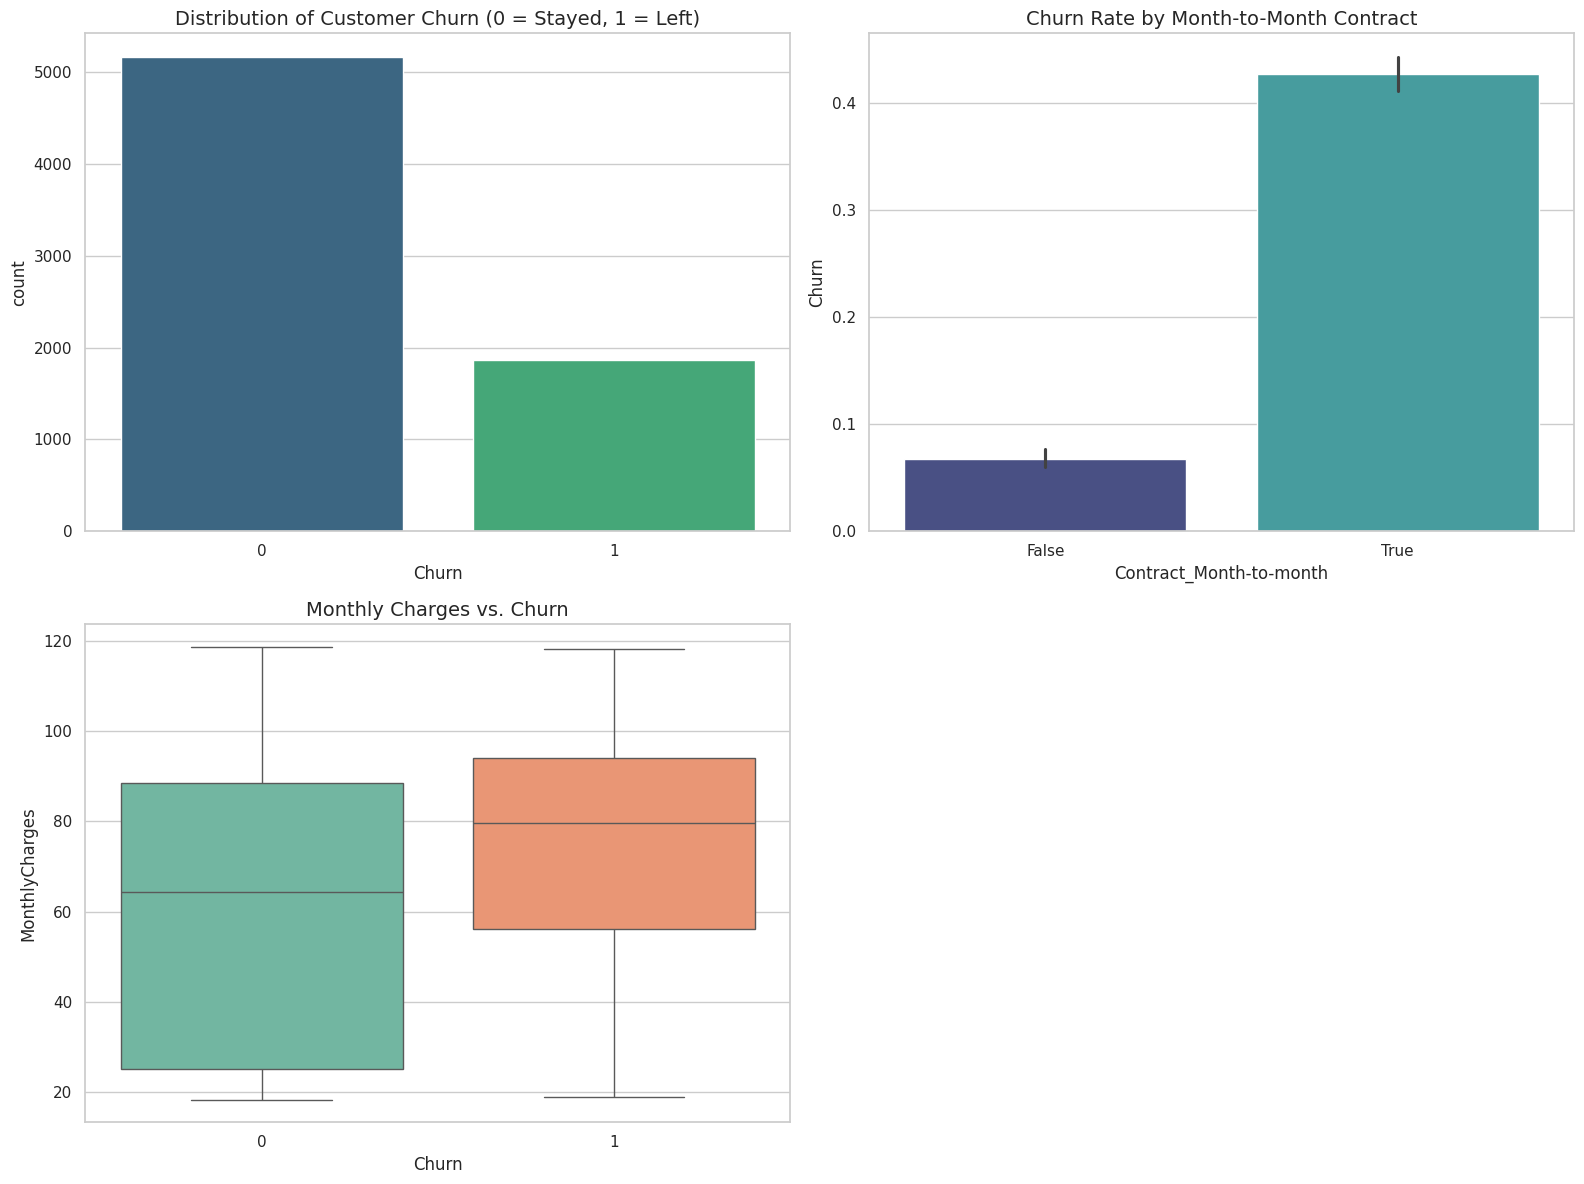

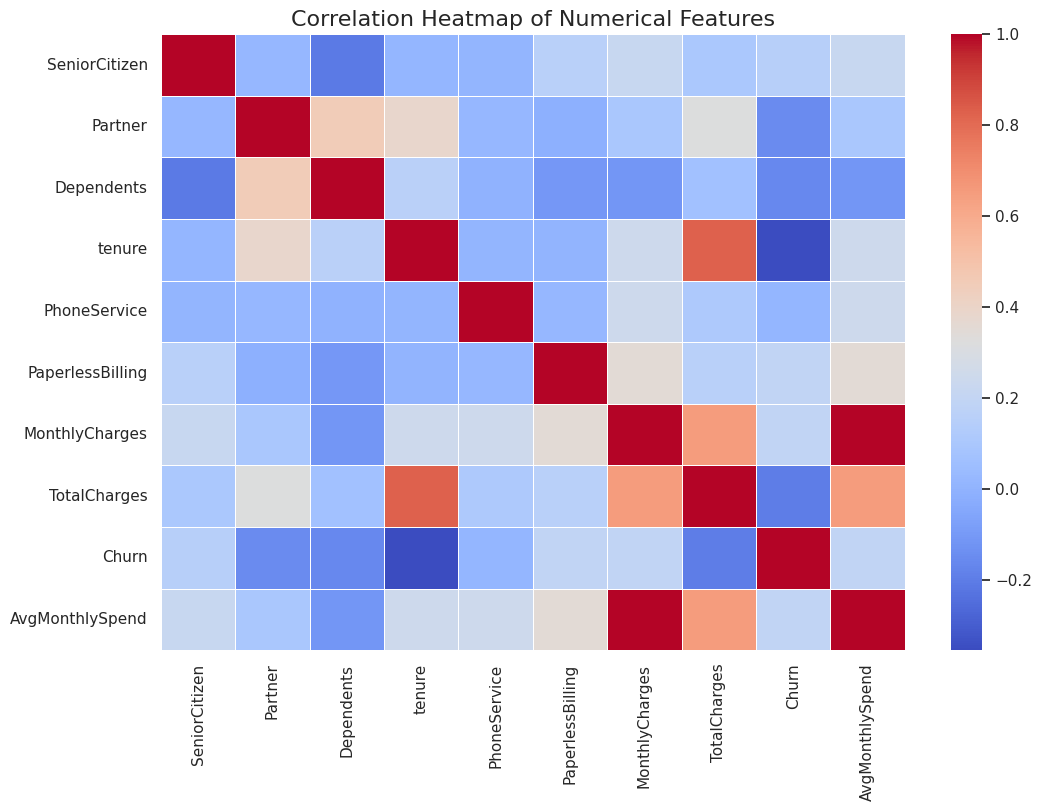

✅ Success! 'Cleaned_Churn_Data.csv' has been saved.


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set the visual style for professional charts
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 12))

# 1. Countplot for Churn (Warning Fixed)
plt.subplot(2, 2, 1)
sns.countplot(x='Churn', data=df_churn, hue='Churn', palette='viridis', legend=False)
plt.title('Distribution of Customer Churn (0 = Stayed, 1 = Left)', fontsize=14)

# 2. Barplot: Contract vs Churn (Warning Fixed)
plt.subplot(2, 2, 2)
sns.barplot(x='Contract_Month-to-month', y='Churn', data=df_churn, hue='Contract_Month-to-month', palette='mako', legend=False)
plt.title('Churn Rate by Month-to-Month Contract', fontsize=14)

# 3. Boxplot: MonthlyCharges by Churn (Warning Fixed)
plt.subplot(2, 2, 3)
sns.boxplot(x='Churn', y='MonthlyCharges', data=df_churn, hue='Churn', palette='Set2', legend=False)
plt.title('Monthly Charges vs. Churn', fontsize=14)

# Adjust layout and show the first set of plots
plt.tight_layout()
plt.show()

# 4. Heatmap of Correlations [cite: 34]

plt.figure(figsize=(12, 8))
# Select only numeric columns so the heatmap math works
numeric_cols = df_churn.select_dtypes(include=[np.number])
sns.heatmap(numeric_cols.corr(), cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.show()

# 5. Deliverable: Save the Cleaned file [cite: 40]
df_churn.to_csv('Cleaned_Churn_Data.csv', index=False)
print("✅ Success! 'Cleaned_Churn_Data.csv' has been saved.")

### **Week 3: Media Data Preparation & Feature Extraction**
Transitioning to the Netflix Titles dataset, this section focuses on cleaning text and date-based metadata. We parse strings into Python `datetime` objects, handle missing values in the director and cast columns, and engineer new analytical features. These features include `release_decade`, a binary `is_movie` indicator, and a cleaned `primary_country` column to track global production.

In [6]:
import pandas as pd
import numpy as np

# 1. Data Understanding & Cleaning [cite: 53]
df_netflix = pd.read_csv('netflix_titles.csv')

# Convert date_added to datetime [cite: 54]
# .str.strip() removes accidental spaces before converting
df_netflix['date_added'] = pd.to_datetime(df_netflix['date_added'].str.strip(), errors='coerce')

# Fill missing data in director, cast
df_netflix['director'] = df_netflix['director'].fillna('Unknown')
df_netflix['cast'] = df_netflix['cast'].fillna('Unknown')

# 2. Feature Engineering [cite: 58]
# Extract release_year and ensure it's numeric [cite: 60]
df_netflix['release_year'] = pd.to_numeric(df_netflix['release_year'], errors='coerce')

# Create release_decade feature
df_netflix['release_decade'] = (df_netflix['release_year'] // 10) * 10

# Create is_movie feature  and extract content_type from the 'type' column [cite: 61]
df_netflix['is_movie'] = df_netflix['type'].apply(lambda x: 1 if x == 'Movie' else 0)

# Country popularity (top 5 countries)
# Many rows have multiple countries separated by commas. We will extract the first (primary) country.
df_netflix['primary_country'] = df_netflix['country'].apply(lambda x: str(x).split(',')[0] if pd.notnull(x) else 'Unknown')
top_5_countries = df_netflix['primary_country'].value_counts().head(5).index.tolist()

print("✅ Week 3 Data Prep Complete!\n")
print("Top 5 Countries producing content:", top_5_countries)
print("\nSnapshot of engineered features:")
print(df_netflix[['type', 'is_movie', 'date_added', 'release_decade', 'primary_country']].head())

✅ Week 3 Data Prep Complete!

Top 5 Countries producing content: ['United States', 'India', 'Unknown', 'United Kingdom', 'Canada']

Snapshot of engineered features:
      type  is_movie date_added  release_decade primary_country
0    Movie         1 2021-09-25            2020   United States
1  TV Show         0 2021-09-24            2020    South Africa
2  TV Show         0 2021-09-24            2020         Unknown
3  TV Show         0 2021-09-24            2020         Unknown
4  TV Show         0 2021-09-24            2020           India


### **Week 4: Data Visualization & Business Insights**
Now that the Netflix data is clean and new features like `release_decade` and `is_movie` have been engineered, we will use Seaborn and Matplotlib to visualize the distribution of content types, historical release trends, and geographical production dominance.

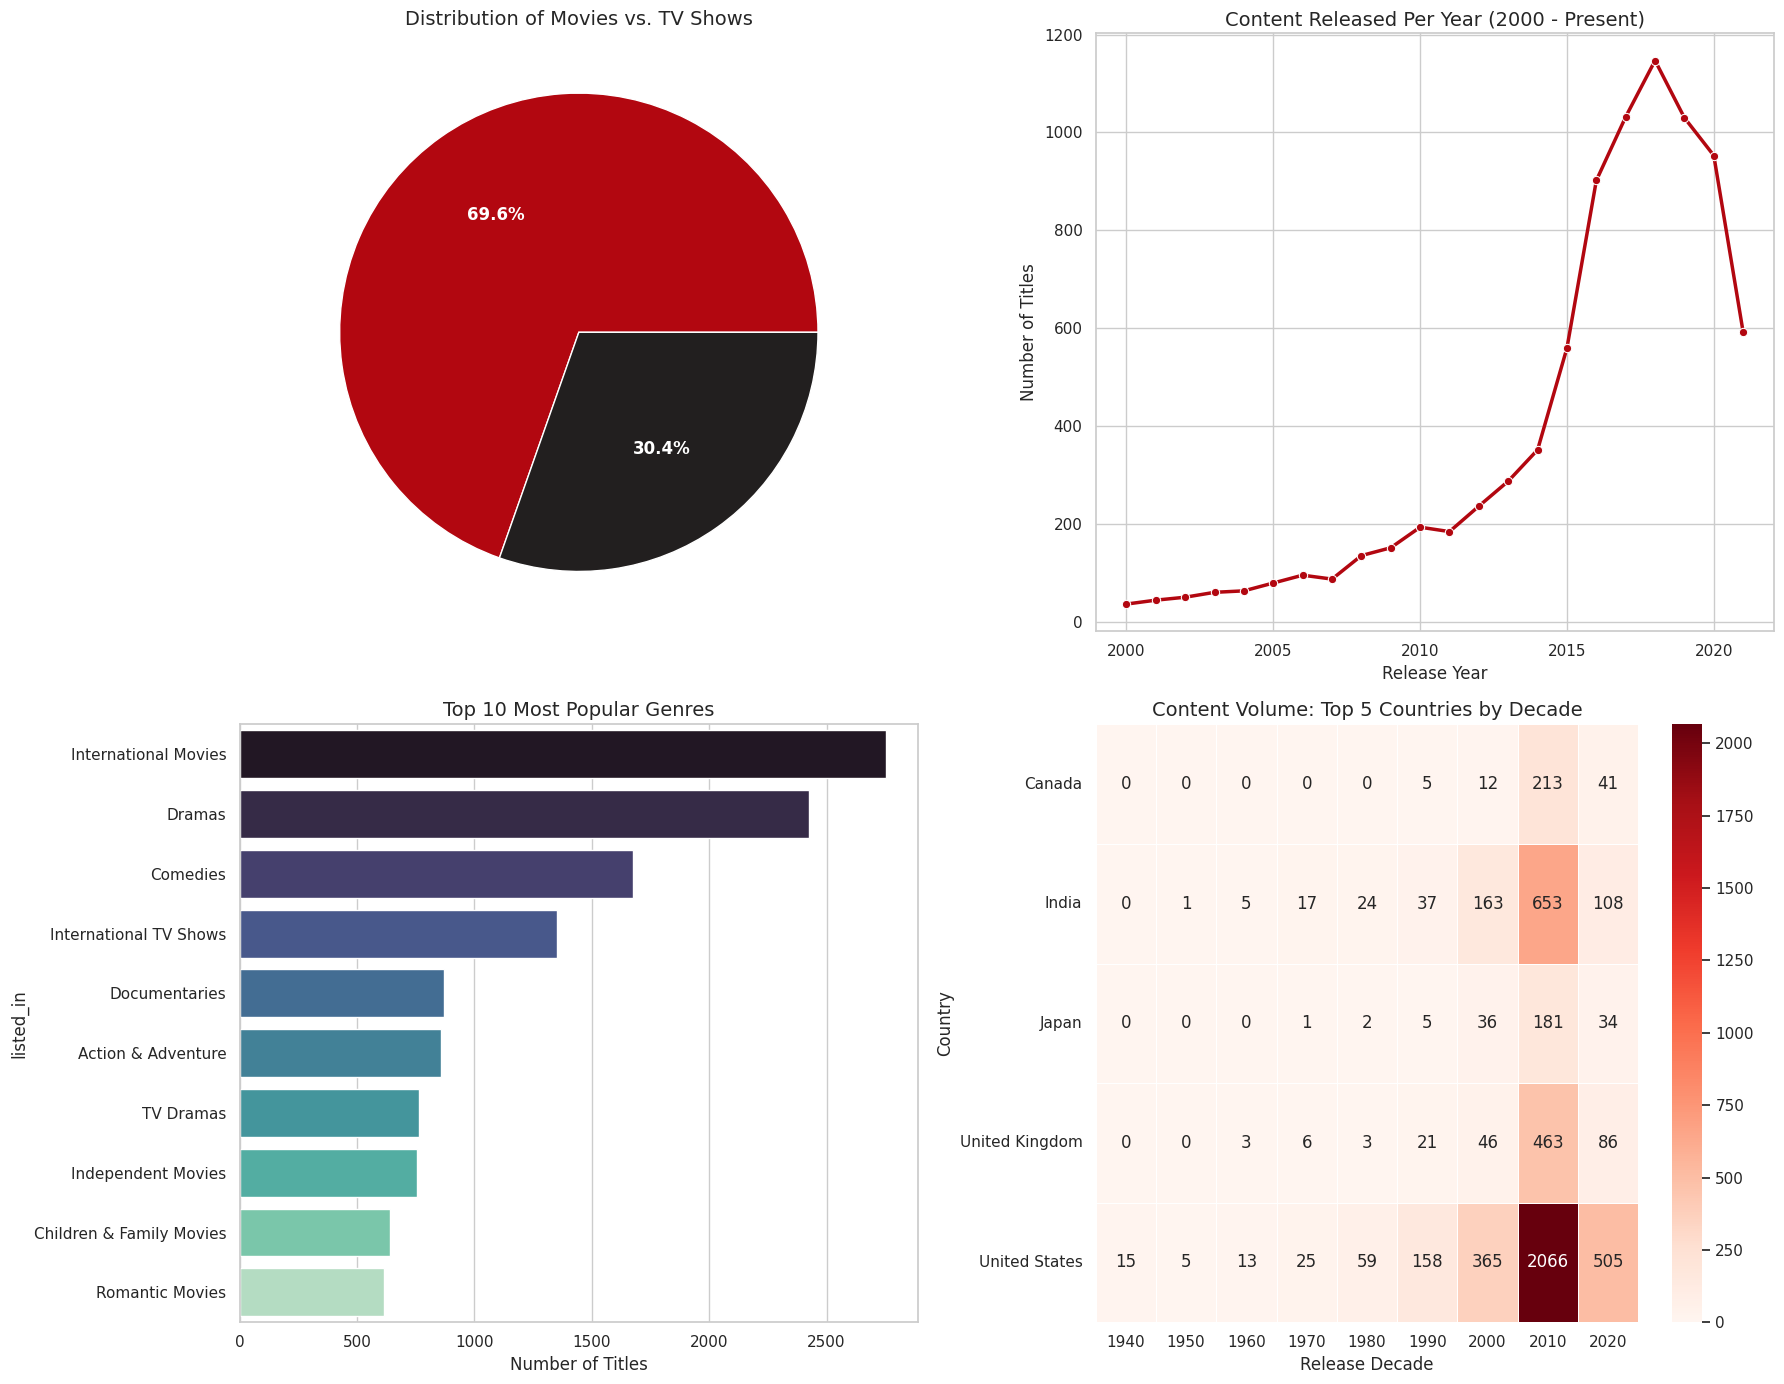

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 14))

# 1. Pie chart: Movie vs TV shows
plt.subplot(2, 2, 1)
type_counts = df_netflix['type'].value_counts()
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', colors=['#b20710', '#221f1f'], textprops={'color':"w", 'weight':'bold'})
plt.title('Distribution of Movies vs. TV Shows', fontsize=14)
# Adding a dark background to make the Netflix red pop
plt.gca().set_facecolor('black')

# 2. Line plot: Content released per year (Post-2000 for clarity)
plt.subplot(2, 2, 2)
yearly_counts = df_netflix[df_netflix['release_year'] >= 2000]['release_year'].value_counts().sort_index()
sns.lineplot(x=yearly_counts.index, y=yearly_counts.values, color='#b20710', linewidth=2.5, marker='o')
plt.title('Content Released Per Year (2000 - Present)', fontsize=14)
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')

# 3. Barplot: Top 10 genres
plt.subplot(2, 2, 3)
# Splitting the 'listed_in' column to get individual genres
genres = df_netflix['listed_in'].str.split(', ').explode()
top_10_genres = genres.value_counts().head(10)
sns.barplot(y=top_10_genres.index, x=top_10_genres.values, hue=top_10_genres.index, palette='mako', legend=False)
plt.title('Top 10 Most Popular Genres', fontsize=14)
plt.xlabel('Number of Titles')

# 4. Heatmap: Country vs content volume
plt.subplot(2, 2, 4)
# Filter out 'Unknown' to get the actual top 5 countries
valid_countries = [c for c in df_netflix['primary_country'].value_counts().index if c != 'Unknown'][:5]
heatmap_data = df_netflix[df_netflix['primary_country'].isin(valid_countries)]
pivot_table = pd.crosstab(heatmap_data['primary_country'], heatmap_data['release_decade'])

sns.heatmap(pivot_table, cmap='Reds', annot=True, fmt='d', linewidths=0.5)
plt.title('Content Volume: Top 5 Countries by Decade', fontsize=14)
plt.xlabel('Release Decade')
plt.ylabel('Country')

plt.tight_layout()
plt.show()